# 01 — Dataset Exploration

This notebook loads the processed 1M-song Parquet file and performs
basic exploratory data analysis (EDA).

**No models are trained here.** This is purely exploratory.

---

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_parquet("../data/processed/songs_1m.parquet")

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,d}")
print(f"Columns: {df.shape[1]}")
df.head()

Dataset shape: (1000000, 27)
Rows: 1,000,000
Columns: 27


,track_id,track_name,isrc,popularity,explicit,artist_idx,artist_id,artist_name,artist_popularity,artist_genres,...,key,mode,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence
0,2plbrEY59IikOBgBGLjaoe,Die With A Smile,USUM72409273,1.00,0,7,0du5cEVh5yTK9QJze8zA0C,Bruno Mars,0.95,"dance pop, pop",...,6,0,0.521,0.5920,-7.777000,0.0304,0.3080,0.0000,0.1220,0.535
1,3sK8wGT43QFpWrvNQsrQya,DtMF,QMFMF2447070,0.98,1,1,4q3ewBCX7sLwd24euuV69X,Bad Bunny,1.00,"urbano latino, trap latino, reggaeton",...,7,0,0.625,0.1310,-27.405001,0.0717,0.1770,0.2180,0.0807,0.032
2,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,USUM72401994,0.98,0,8,6qqNVTkY8uBg9cP3Jd7DAH,Billie Eilish,0.95,"pop, art pop",...,2,1,0.747,0.5070,-10.171000,0.0358,0.2000,0.0608,0.1170,0.438
3,2lTm559tuIvatlT1u0JYG2,BAILE INoLVIDABLE,QMFMF2447057,0.96,1,1,4q3ewBCX7sLwd24euuV69X,Bad Bunny,1.00,"urbano latino, trap latino, reggaeton",...,10,1,0.168,0.0033,-46.112999,0.0615,0.1920,0.7900,0.1120,0.219
4,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,USUG12400910,0.96,1,5,2YZyLoL8N0Wb9xBt1NhZWg,Kendrick Lamar,0.97,"hip hop, rap, conscious hip hop, west coast rap",...,1,1,0.898,0.4720,-7.001000,0.0776,0.0107,0.0000,0.1410,0.214


## 2. Dataset Information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 27 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   track_id           1000000 non-null  str    
 1   track_name         1000000 non-null  str    
 2   isrc               999925 non-null   str    
 3   popularity         1000000 non-null  float64
 4   explicit           1000000 non-null  int64  
 5   artist_idx         1000000 non-null  int64  
 6   artist_id          1000000 non-null  str    
 7   artist_name        1000000 non-null  str    
 8   artist_popularity  1000000 non-null  float64
 9   artist_genres      1000000 non-null  str    
 10  artist_genre_idx   1000000 non-null  int64  
 11  album_id           1000000 non-null  str    
 12  album_name         1000000 non-null  str    
 13  release_year       1000000 non-null  int64  
 14  duration           1000000 non-null  int64  
 15  time_signature     1000000 non-null  int64  

In [4]:
df.describe(include="all")

,track_id,track_name,isrc,popularity,explicit,artist_idx,artist_id,artist_name,artist_popularity,artist_genres,...,key,mode,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence
count,1000000,1000000,999925,1000000.000000,1000000.000000,1.000000e+06,1000000,1000000,1000000.000000,1000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
unique,1000000,691635,913357,NaN,NaN,NaN,143334,140897,NaN,24218,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2plbrEY59IikOBgBGLjaoe,Intro,CH7812531303,NaN,NaN,NaN,3meJIgRw7YleJrmbpbJK6S,Die drei ???,NaN,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,288,17,NaN,NaN,NaN,5809,5809,NaN,223476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.446393,0.174787,3.575422e+04,NaN,NaN,0.566380,NaN,...,5.284080,0.599643,0.602740,0.603149,-8.995287,0.107331,0.342147,0.144214,0.197325,0.490627
std,NaN,NaN,NaN,0.076384,0.379785,1.072173e+05,NaN,NaN,0.157621,NaN,...,3.585476,0.489971,0.177995,0.247023,6.286669,0.135828,0.320417,0.307393,0.168187,0.259492
min,NaN,NaN,NaN,0.360000,0.000000,1.000000e+00,NaN,NaN,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,0.390000,0.000000,2.317000e+03,NaN,NaN,0.460000,NaN,...,2.000000,0.000000,0.498000,0.455000,-10.263000,0.037000,0.051300,0.000000,0.098600,0.282000
50%,NaN,NaN,NaN,0.420000,0.000000,1.072200e+04,NaN,NaN,0.560000,NaN,...,5.000000,1.000000,0.626000,0.639000,-7.261000,0.052700,0.239000,0.000000,0.126000,0.489000
75%,NaN,NaN,NaN,0.480000,0.000000,3.685325e+04,NaN,NaN,0.680000,NaN,...,8.000000,1.000000,0.732000,0.796000,-5.334000,0.112000,0.594000,0.014000,0.245000,0.699000


## 3. Missing Values

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

print("Missing values (sorted descending):")
missing_summary

Missing values (sorted descending):


,Missing Count,Missing %
isrc,75,0.01
track_id,0,0.00
track_name,0,0.00
popularity,0,0.00
explicit,0,0.00
artist_idx,0,0.00
artist_id,0,0.00
artist_name,0,0.00
artist_popularity,0,0.00
artist_genres,0,0.00


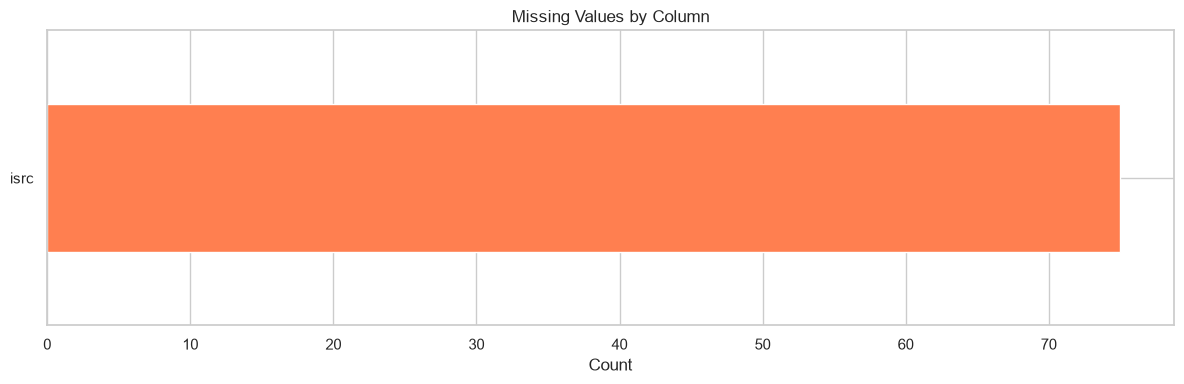

In [8]:
# Visualize missing values (only columns with missing data)
cols_with_missing = missing[missing > 0]

if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(cols_with_missing) * 0.4)))
    cols_with_missing.plot(kind="barh", ax=ax, color="coral")
    ax.set_title("Missing Values by Column")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

## 4. Duplicate Analysis

In [9]:
# Duplicate track IDs
if "track_id" in df.columns:
    dup_track_id = df["track_id"].duplicated().sum()
    print(f"Duplicate track_id values: {dup_track_id:,d}")
    print(f"Unique track_id values:    {df['track_id'].nunique():,d}")
else:
    print("'track_id' column not found.")

Duplicate track_id values: 0
Unique track_id values:    1,000,000


In [10]:
# Duplicate track_name + artist_name combinations
name_cols = [c for c in ["track_name", "artist_name"] if c in df.columns]

if len(name_cols) == 2:
    dup_name_artist = df.duplicated(subset=name_cols).sum()
    print(f"Duplicate (track_name + artist_name) pairs: {dup_name_artist:,d}")
elif len(name_cols) == 1:
    dup_single = df.duplicated(subset=name_cols).sum()
    print(f"Duplicate {name_cols[0]} values: {dup_single:,d}")
else:
    print("Neither 'track_name' nor 'artist_name' columns found.")

print("\nNote: Duplicates are reported but NOT removed at this stage.")

Duplicate (track_name + artist_name) pairs: 93,389

Note: Duplicates are reported but NOT removed at this stage.


## 5. Numerical Feature Distributions

In [11]:
# Audio features to inspect (only those that exist)
candidate_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration", "duration_ms", "popularity",
]

audio_features = [c for c in candidate_features if c in df.columns]
print(f"Available audio features for analysis: {audio_features}")

Available audio features for analysis: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration', 'popularity']


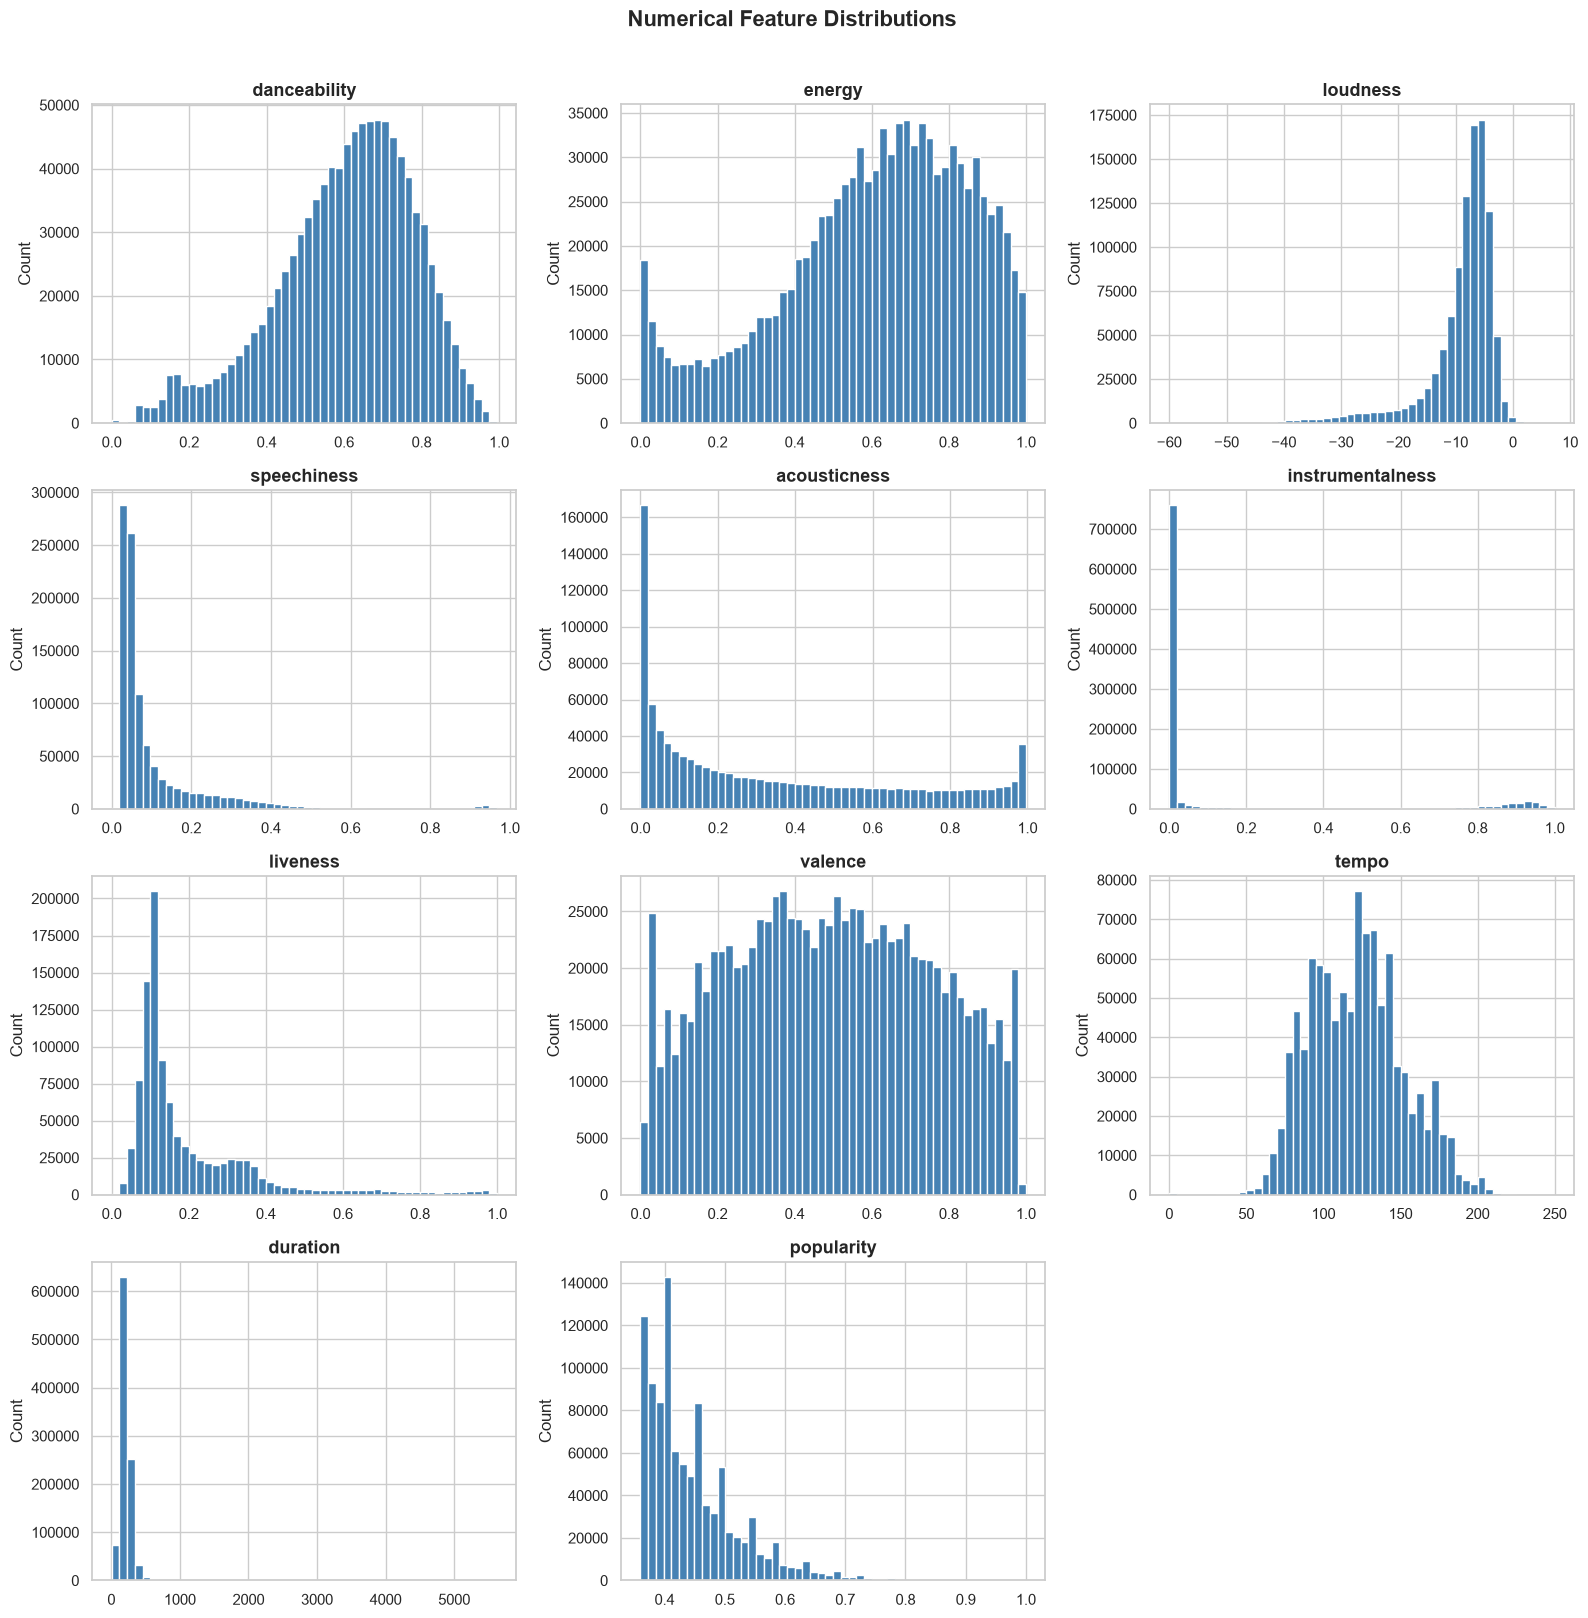

In [12]:
if audio_features:
    n_features = len(audio_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, feature in enumerate(audio_features):
        ax = axes[i]
        df[feature].dropna().hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
        ax.set_title(feature, fontsize=13, fontweight="bold")
        ax.set_ylabel("Count")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Numerical Feature Distributions", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No audio features found for histogram plotting.")

## 6. Correlation Matrix

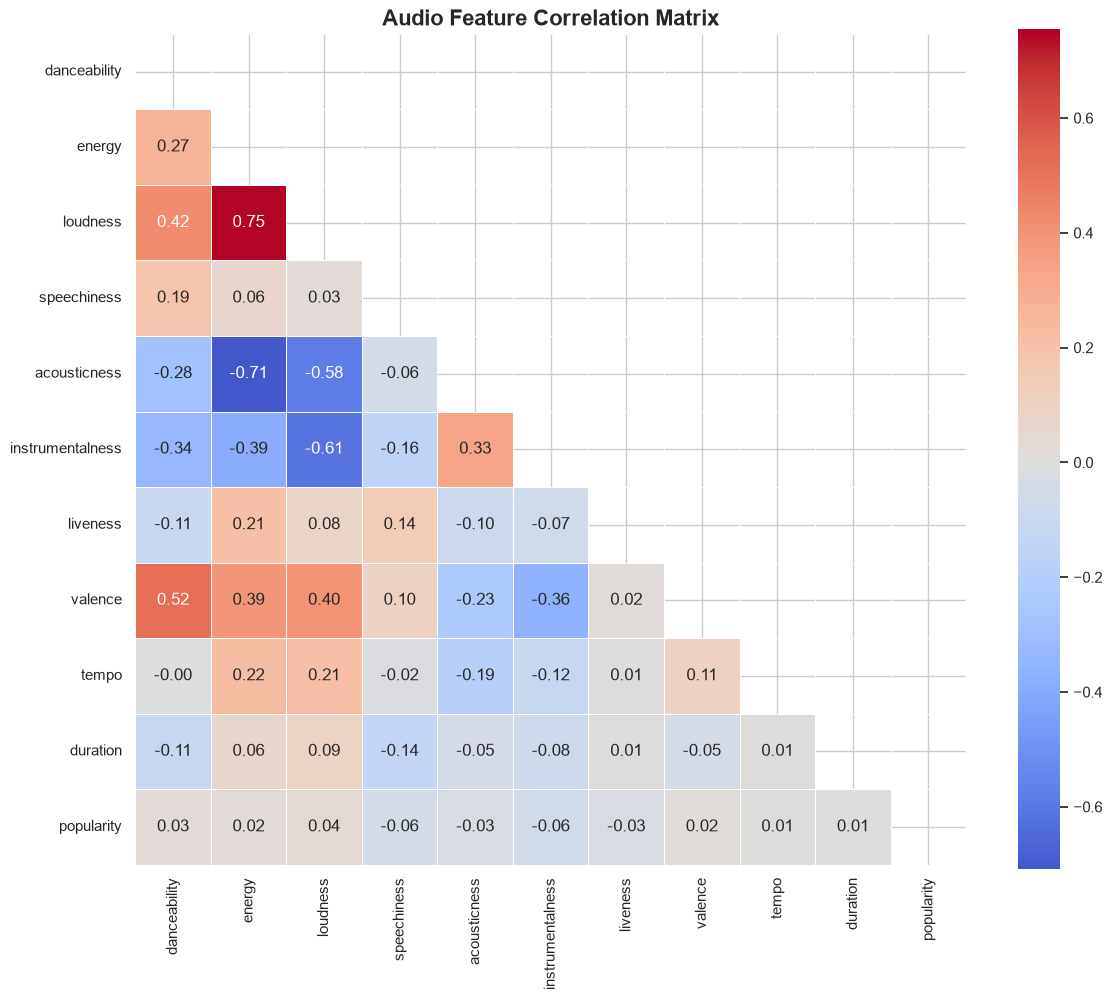

In [13]:
# Use all available numeric audio features for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Prefer the known audio features if available, else fall back to all numeric
corr_cols = [c for c in audio_features if c in numeric_cols] if audio_features else numeric_cols

if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title("Audio Feature Correlation Matrix", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a correlation matrix.")

---

## Summary

This notebook performed basic EDA on the 1M-song dataset:

1. **Loaded** the Parquet file and confirmed its shape
2. **Inspected** data types and basic statistics
3. **Measured** missing values
4. **Counted** duplicate track IDs and name+artist pairs
5. **Plotted** distributions of audio features
6. **Computed** a correlation matrix for numerical features

**Next steps** (later phases):
- Data cleaning and imputation
- Feature engineering
- Content-based recommendation model